# Stripe Collapse Probabilities
This notebook has been created to investigate the fact that for some sites the return periods selected for the MSA do not cause a sufficient number of collapses to facilitate the fitting of a fragility curve. Obviously the initial guess of the failure window was not accurate enough.

Using the results of some previous IDA analyses the resulting fragility curves the expected number of collapses expected for the IML of each stripe can be estimated. Following that the IDA results can also be used to determine a suitable window of IMLs for the MSA be choosing IMLs/RTPs at each site that will cause a suitable number of collapses

## Upstream / downstream

**Upstream** (all must have been run):

- `014-sdof_validation_and_fragilities` -> `mdof_fragility_curves.pickle`,
  `sdof_fragility_curves.pickle` in `cfg["proc_data"]["sdof_fragility_curves"]`
- `012-mdof_casestudy_analyses` -> `cfg["proc_data"]["dc2_casestudy_dataset"]`
- `004-psha_results` -> the AvgSA(0-3s) hazard curves for the 60 sites
- `011-create_site_casestudies_and_analyses` -> `site_designs_summary.csv`

**Downstream:** the stripe IMLs chosen here are used by
`050_setup_msa_runs_for_complete_sites`.

> Notebooks `012`-`014` were previously numbered `012`/`013`/`014`/`016` (and earlier still
> `wp1pt4pt1e`). See `README.md` in this folder for the full dependency order.


In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd 
from scipy.stats import lognorm
from scipy.optimize import linear_sum_assignment

from phd_project.config import config
from hazrisk.hazard import mafe_to_poe

cfg = config.load_config()

In [3]:
HAZ_ROOT = cfg["proc_data"]["site_hazard"]
ANALYSIS_ROOT = cfg["analysis_data"]["dc2_sdof_fitting"] 

In [ ]:
# Load the hazard data
# with open(HAZ_ROOT / "AvgSA_03_disagg_stats_60sites.pickle", "rb") as file:
#     disagg_stats_03 = pickle.load(file)

# 004-psha_results.ipynb writes all three truncation levels in one flat structure:
#   hcs[site_id]["AvgSA"][stat] -> ndarray (n_iml, 2), col 0 = IML [g], col 1 = MAFE
with open(HAZ_ROOT / "AvgSA_03_hazard_curves_60sites_3sig.pickle", "rb") as file:
    hcs_03_3sig = pickle.load(file)

with open(HAZ_ROOT / "AvgSA_03_hazard_curves_60sites_4sig.pickle", "rb") as file:
    hcs_03_4sig = pickle.load(file)

with open(HAZ_ROOT / "AvgSA_03_hazard_curves_60sites_5sig.pickle", "rb") as file:
    hcs_03_5sig = pickle.load(file)

sorted_keys = sorted(hcs_03_3sig.keys())

hcs_03_mean = {k : hcs_03_3sig[k]["AvgSA"]["mean"] for k in sorted_keys}
hcs_03_median = {k : hcs_03_3sig[k]["AvgSA"]["quantile-0.5"] for k in sorted_keys}
hcs_03_trunc4_mean = {k : hcs_03_4sig[k]["AvgSA"]["mean"] for k in sorted_keys}
hcs_03_trunc5_mean = {k : hcs_03_5sig[k]["AvgSA"]["mean"] for k in sorted_keys}

# Load the casestudy design data
# Site independent case studies
with open(cfg["proc_data"]["dc2_casestudy_dataset"], "rb") as f:
    reference_designs = pickle.load(f)

reference_designs = reference_designs.set_index("name")
reference_designs = reference_designs.drop(columns="index")
reference_designs["Vb_coeff"] = reference_designs["design_baseshear"] / (reference_designs["seismic_mass"] * 9.81)

# site dependent data
sitespec_design_summary_fp = Path(cfg["models"]["casestudy_designs_site_specific"] / "site_designs_summary.csv")
sitespec_designs = pd.read_csv(sitespec_design_summary_fp)


Data relating to the design of the reference casestudy designs. The reference casestudy designs have been design for a range of base shear coefficients that encompasses the range of values expected in Europe

In [5]:
reference_designs

,n_storeys,roof_height,V_wind_GQWSI_LC1,V_wind_GQWSI_LC2,V_wind_GQWSI_LC3,T1_GQWSI_LC1,T1_GQWSI_LC2,T1_GQWSI_LC3,gravity_frame_elastic_baseshear,gravity_design_equivalent_seismic_baseshear,...,seismic_F6,seismic_F7,seismic_V1,seismic_V2,seismic_V3,seismic_V4,seismic_V5,seismic_V6,seismic_V7,Vb_coeff
name,,,,,,,,,,,,,,,,,,,,,
3s_cbf_dc2_10,3,10500,19855.845357,33093.075595,19855.845357,0.884937,0.864221,0.875094,1.940971e+05,79905.842715,...,NaN,NaN,17069.007996,51207.023987,9.692758e+04,NaN,NaN,NaN,NaN,0.031657
3s_cbf_dc2_20,3,10500,19855.845357,33093.075595,19855.845357,0.767450,0.749553,0.759012,3.858510e+05,79905.842715,...,NaN,NaN,39119.717226,117359.151677,2.221441e+05,NaN,NaN,NaN,NaN,0.072553
3s_cbf_dc2_31,3,10500,19855.845357,33093.075595,19855.845357,0.634683,0.621273,0.629798,7.502664e+05,79905.842715,...,NaN,NaN,91541.379705,274624.139115,5.198243e+05,NaN,NaN,NaN,NaN,0.169777
3s_cbf_dc2_41,3,10500,19855.845357,33093.075595,19855.845357,0.562798,0.551065,0.558700,9.831009e+05,79905.842715,...,NaN,NaN,135192.440416,405577.321247,7.676999e+05,NaN,NaN,NaN,NaN,0.250735
3s_cbf_dc2_51,3,10500,19855.845357,33093.075595,19855.845357,0.537063,0.525928,0.533244,1.589369e+06,79905.842715,...,NaN,NaN,164623.935396,493871.806189,9.348288e+05,NaN,NaN,NaN,NaN,0.305320
3s_cbf_dc2_61,3,10500,19855.845357,33093.075595,19855.845357,0.516356,0.505608,0.512619,1.876711e+06,79905.842715,...,NaN,NaN,192517.767849,577553.303547,1.093226e+06,NaN,NaN,NaN,NaN,0.357053
3s_cbf_dc2_71,3,10500,19855.845357,33093.075595,19855.845357,0.499045,0.488803,0.495654,2.156086e+06,79905.842715,...,NaN,NaN,218973.773887,656921.321660,1.243458e+06,NaN,NaN,NaN,NaN,0.406120
3s_cbf_dc2_102,3,10500,19855.845357,33093.075595,19855.845357,0.456553,0.446897,0.453017,2.971518e+06,79905.842715,...,NaN,NaN,291850.005736,875550.017208,1.657291e+06,NaN,NaN,NaN,NaN,0.541280
3s_cbf_dc2_122,3,10500,19855.845357,33093.075595,19855.845357,0.437225,0.428202,0.434177,3.456972e+06,79905.842715,...,NaN,NaN,331534.014792,994602.044377,1.882640e+06,NaN,NaN,NaN,NaN,0.614880


Data relating to the site specific designs of the casestudy strucutre

In [6]:
sitespec_designs.sort_values("Vb_coeff")

,tag,S_alpha_RP,design_in_json,design_out_json,pickle,success,Vb,Wt,Vb_coeff,T,q_design,S_r
22,3s_cbf_dc2_site29,0.134319,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,7.990584e+04,3061800.0,0.026098,0.719978,1.429709,0.026098
34,3s_cbf_dc2_site4,0.137161,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,7.990584e+04,3061800.0,0.026098,0.719978,1.459951,0.026098
58,3s_cbf_dc2_site8,0.143228,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,7.990584e+04,3061800.0,0.026098,0.719978,1.524535,0.026098
11,3s_cbf_dc2_site19,0.181265,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,7.990584e+04,3061800.0,0.026098,0.719978,1.929403,0.026098
20,3s_cbf_dc2_site27,0.192986,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,8.046056e+04,3061800.0,0.026279,0.719978,2.040000,0.026279
19,3s_cbf_dc2_site26,0.193018,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,8.047403e+04,3061800.0,0.026283,0.719978,2.040000,0.026283
0,3s_cbf_dc2_site0,0.209594,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,8.738487e+04,3061800.0,0.028540,0.719978,2.040000,0.028540
18,3s_cbf_dc2_site25,0.215247,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,8.974180e+04,3061800.0,0.029310,0.719978,2.040000,0.029310
23,3s_cbf_dc2_site3,0.229135,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,9.714591e+04,3061800.0,0.031728,0.708017,2.040000,0.031728
45,3s_cbf_dc2_site5,0.242517,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,C:\Users\clemettn\Documents\phd\casestudy_stru...,True,1.060324e+05,3061800.0,0.034631,0.686561,2.040000,0.034631


## 1. Reference collapse fragilities

The nine site-independent reference designs (all 3-storey) have IDA-derived collapse fragilities in
`mdof_fragility_curves.pickle`. The medians are in **mm/s²** of AvgSA(0-3s), whereas the hazard IMLs
in `disagg_stats_03` are in **g**, so a factor of `g = 9810` is needed to compare them.

Note the fragilities are **not monotonic** in `Vb_coeff`: `3s_cbf_dc2_10` (the weakest design) has a
*higher* collapse median than `3s_cbf_dc2_20`. This is almost certainly because `_10` is wind-governed
- all 3-storey designs share the same wind base shear - so its members are stronger than its seismic
design coefficient implies.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from scipy.stats import lognorm

from hazrisk.hazard import poe_to_rtp

G = 9810.0  # mm/s^2, to convert the hazard IMLs (g) into the fragility units
N_RECORDS = 30  # records per stripe, uniform across all 360 (site, poe) ensembles
LO, HI = 3, 27  # collapses out of N_RECORDS over which a binomial-MLE fit is well conditioned

with open(cfg["proc_data"]["sdof_fragility_curves"] / "mdof_fragility_curves.pickle", "rb") as file:
    mdof_fragilities = pickle.load(file)

refs = pd.DataFrame(
    [
        {
            "name": name,
            "Vb_coeff": reference_designs.loc[name, "Vb_coeff"],
            "median": frag.median,
            "dispersion": frag.dispersion,
        }
        for name, frag in mdof_fragilities.items()
    ]
).sort_values("Vb_coeff", ignore_index=True)

# np.interp requires ascending x; the y-values (P[C]) need not be monotonic
assert refs["Vb_coeff"].is_monotonic_increasing

vb_ref = refs["Vb_coeff"].to_numpy()
refs

,name,Vb_coeff,median,dispersion
0,3s_cbf_dc2_10,0.031657,3752.592658,0.188868
1,3s_cbf_dc2_20,0.072553,3210.207261,0.160847
2,3s_cbf_dc2_31,0.169777,4644.606172,0.201725
3,3s_cbf_dc2_41,0.250735,5762.196292,0.225877
4,3s_cbf_dc2_51,0.305320,6452.143188,0.254091
5,3s_cbf_dc2_61,0.357053,7121.581405,0.251887
6,3s_cbf_dc2_71,0.406120,8099.209302,0.237370
7,3s_cbf_dc2_102,0.541280,9315.301570,0.240261
8,3s_cbf_dc2_122,0.614880,10396.599263,0.246119


## 2. Interpolated Site-Specific Collapse Fragilities

Applying the same interpolation over a fine IML grid gives each site an interpolated collapse curve. Plotting
the 6 stripe IMLs on top of it shows directly how far short of collapse the current MSA return periods fall,
and gives the IML window we would actually need to target.

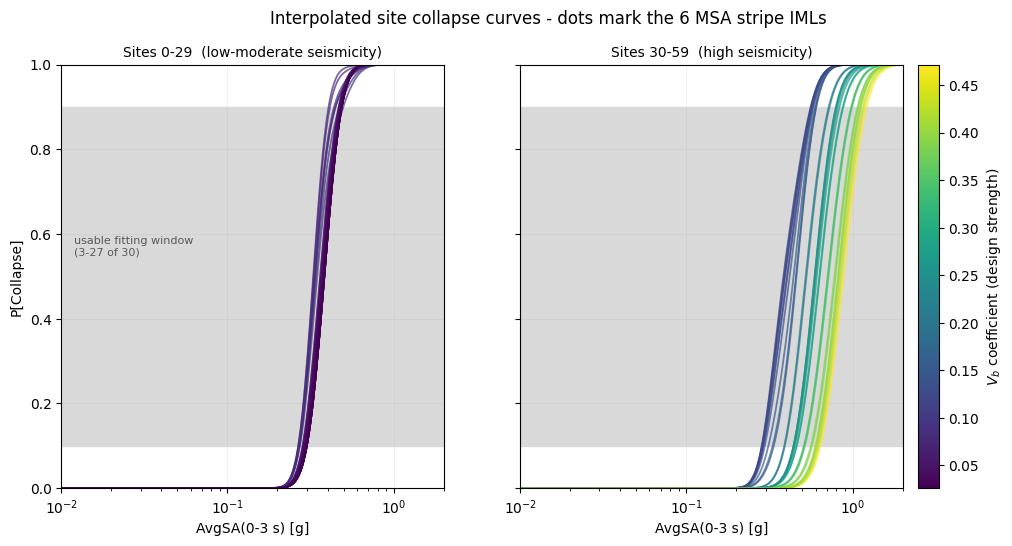

In [ ]:
IML_GRID = np.logspace(np.log10(0.01), np.log10(3.0), 300)  # g
PC_GRID_REF = lognorm.cdf(
    IML_GRID[:, None] * G,
    refs["dispersion"].to_numpy()[None, :],
    scale=refs["median"].to_numpy()[None, :],
)  # (n_grid, n_refs)

CMAP = plt.get_cmap("viridis")  # sequential: Vb_coeff is a magnitude
NORM = Normalize(vmin=sitespec_designs["Vb_coeff"].min(), vmax=sitespec_designs["Vb_coeff"].max())
FLOOR = 1e-2  # axis floor for the log y-scale
GROUPS = [
    (range(0, 30), "Sites 0-29  (low-moderate seismicity)"),
    (range(30, 60), "Sites 30-59  (high seismicity)"),
]

def site_pc_curve(vb_coeff):
    """P[C] over IML_GRID for a site of the given strength, same interpolation as the stripes."""
    return np.array([np.interp(vb_coeff, vb_ref, row) for row in PC_GRID_REF])


def iml_at_p(vb_coeff, p):
    """The IML (g) at which a site's interpolated collapse curve reaches probability p."""
    return float(np.interp(p, site_pc_curve(vb_coeff), IML_GRID))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True, sharex=True)
site_vb = sitespec_designs.set_index("site_id")["Vb_coeff"].sort_index()

pcs_to_interp = np.arange(1, 10) / 10
site_specific_fcs = {}
pcs = []

for ax, (site_range, panel_title) in zip(axes, GROUPS):
    ax.axhspan(LO / N_RECORDS, HI / N_RECORDS, color="0.85", zorder=0)
    for site_id in site_range:
        colour = CMAP(NORM(site_vb[site_id]))
        fc = site_pc_curve(site_vb[site_id])
        site_specific_fcs[site_id] = fc
        pcs.append(np.interp(pcs_to_interp, fc, IML_GRID))
        ax.plot(IML_GRID, fc, color=colour, lw=1.3, alpha=0.7)

    ax.set_xscale("log")
    ax.set_xlim(0.01, 2.0)
    ax.set_ylim(0, 1)
    ax.set_xlabel("AvgSA(0-3 s) [g]")
    ax.set_title(panel_title, fontsize=10)
    ax.grid(alpha=0.25, lw=0.5)

axes[0].set_ylabel("P[Collapse]")
axes[0].text(0.012, 0.55, f"usable fitting window\n({LO}-{HI} of {N_RECORDS})", fontsize=8, color="0.35")
cbar = fig.colorbar(ScalarMappable(norm=NORM, cmap=CMAP), ax=axes, pad=0.015)
cbar.set_label("$V_b$ coefficient (design strength)")
fig.suptitle("Interpolated site collapse curves - dots mark the 6 MSA stripe IMLs", fontsize=12)
plt.show()

pcs = np.vstack(pcs)

In [12]:
bound_10pc_lowmod = [pcs[:30, 0].min(), pcs[:30, 0].max()]
bound_50pc_lowmod = [pcs[:30, 4].min(), pcs[:30, 4].max()]
bound_80pc_lowmod = [pcs[:30, 7].min(), pcs[:30, 7].max()]

bound_10pc_high = [pcs[30:, 0].min(), pcs[30:, 0].max()]
bound_50pc_high = [pcs[30:, 4].min(), pcs[30:, 4].max()]
bound_80pc_high = [pcs[30:, 7].min(), pcs[30:, 7].max()]

lowmod_bounds = [bound_80pc_lowmod, bound_50pc_lowmod, bound_10pc_lowmod]
high_bounds = [bound_80pc_high, bound_50pc_high, bound_10pc_high]
pc_bounds = [lowmod_bounds, high_bounds]

Text(0.5, 0.98, 'Site hazard curves - x marks the last point of a curve clipped by the truncation level')

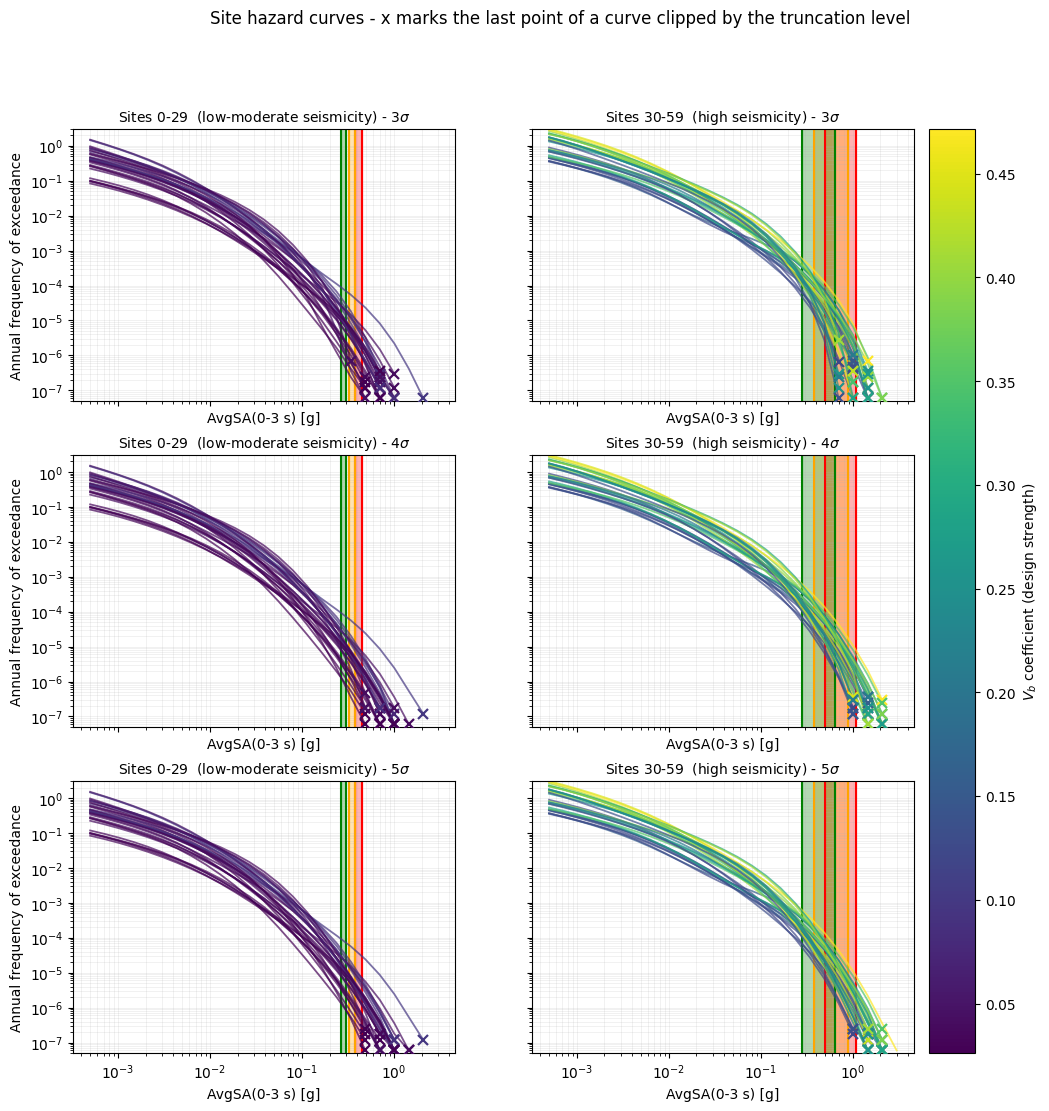

In [13]:
# Same layout/colouring as above, but the site hazard curves rather than the collapse curves.
# Hazard POE collapses to <= 0 at the truncation ceiling (truncation_level = 3), so those points
# cannot be shown on a log axis. We plot only the strictly-positive part of each curve and, where a
# curve is clipped, mark its last visible (lowest-POE) point with an "x" so it is obvious which
# curves ran into the ceiling and which reach the axis floor on their own.
fig, axes = plt.subplots(3, 2, figsize=(13, 12), sharey=True, sharex=True)

y1 = 3e-8
y2 = 4

hc_models = [hcs_03_mean, hcs_03_trunc4_mean, hcs_03_trunc5_mean]
hc_trunc_levels = [3, 4, 5]

for ii, (hc_model, hc_trunc) in enumerate(zip(hc_models, hc_trunc_levels)):
    for jj, ((site_range, panel_title), bounds) in enumerate(zip(GROUPS, pc_bounds)):
        
        ax = axes[ii, jj]
        for pc, colour in zip(bounds, ("r", "orange", "g")):
            for v in pc:
                ax.vlines(v, y1, y2, color=colour)
            ax.fill_betweenx([y1, y2], *pc, color=colour, alpha=0.3)
        
        for site_id in site_range:
            # if not site_id in [4, 8, 19, 26, 27, 28]:
            #     continue
            colour = CMAP(NORM(site_vb[site_id]))
            hc = hc_model[site_id]
            iml, mafe = hc[:, 0], hc[:, 1]
            pos = mafe > 0  # log axis: drop the non-positive tail
            ax.plot(iml[pos], mafe[pos], color=colour, lw=1.3, alpha=0.7)
            if not pos.all():  # curve was clipped -> flag the last shown point
                last = np.flatnonzero(pos)[-1]
                ax.plot(
                    iml[last], mafe[last], ls="none", marker="x", ms=7,
                    mec=colour, mew=1.6, zorder=3,
                )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("AvgSA(0-3 s) [g]")
        ax.set_title(rf"{panel_title} - {hc_trunc}$\sigma$", fontsize=10)
        ax.grid(alpha=0.25, which="both", lw=0.5)

for ax in axes[:, 0]:
    ax.set_ylabel("Annual frequency of exceedance")
    ax.set_ylim(5e-8, 3) 
cbar = fig.colorbar(ScalarMappable(norm=NORM, cmap=CMAP), ax=axes, pad=0.015)
cbar.set_label("$V_b$ coefficient (design strength)")
fig.suptitle("Site hazard curves - x marks the last point of a curve clipped by the truncation level", fontsize=12)

How to interpret the plot above... Each coloured band represents the extent of the IMLs at which Probability of Collapse = 10% (g) / 50% (or.) / 80% (r) is expected to occur, based on the approximate fragility curves obtained in the first plot of this section.

By drawing horizontal lines at different annual frequency of exceedances we can visually see at which sites we expect to see what % of collapses. If the hazard curve crosses through a coloured region above the horitontal line then we would expect at least X% failures (depending on the colour) for the given MAFE and all is well, however the "x" indicating the lowest calculable MAFE must also lie below the horizontal MAFE line otherwise OpenQuake can't calculate the disaggreagation. If the hazard curves cross below the line then we expect less than X% failures. If the hazard curve terminates (with an x) this is the maximum IML that can be computed given the truncation level used in the hazard analysis. (e.g. truncation = 3 limits the calculation to ground motion values 3*sigma away from the mean.) To extend the hazard curves further we would need to increase this truncation level and except more and more extraordinary events (e.g. ground motion imls that we would see only 0.00315% of the time for a given rupture scenario, if 4sigma was the truncation limit.) These are very rare events and may not actually be physically possible, although including them will allow hazard to be calculated. The literature is divided on whether a truncation limit needs to be enforced on not (see obsidian notes) What this indicates is that the hazard of the site is low relative to the strength of the buildings. The GMMs are also less accurate in this 4sigma region because the fits generally focus on the body up to max 3sigma.

I think the solution will be getting a bit more granular and site specific about what RTPs we use for the record selection. We probably need a few generally groups + a couple of special cases. For example considering the high sites; at a MAFE of 1e-6 most sites (except 2) will be expecting Pcs around 50-90% which is perfect. An I wouldn't want to use a more frequent period than say 4e-5 as that is the point where the last hazard curve starts to cross the 10% line.

It is worth noting that there is significant variation in the MAFEs that correspond to each part of the fragility curve across the considered sites. It would be advantageous to select a custom set of the RTPs for each site because then we can run a much smaller number of well targeted calculations per site (e.g. 4 stripes x 30 records = 120) to get the fragility curves. Based on Baker (2015) a set of stripes centred on the median and stretching from 0.6x to 1.8x the expected median would be a good range. With our AvgSA curves we have quite a low dispersion so these IML values don't really work well. I will target P[C] = 0.2, 0.4, 0.6, 0.8. That should cover the range well and allow for some wiggle room so that risk that we get all collapses or no collapses is not too high.

It is possible in Openquake to disaggregate directly on a given IML level for all sites and not just the through poes. That is advantageous because by selecting a few IMLs we can target the important parts of the fragility curve much more accurately than if we were choosing RTPs. Because we only need to select and run a relatively small number of IMLs compared to site-specific RTPs the Openquake calculation should also be more efficient. We just need to work out a good combination of IMLs

### IMLs for Disaggregation Calculations

In [ ]:
# choosen manually by inspection to try and make sure we can get 4 good points per fc
imls = np.array([0.285, 0.310, 0.330, 0.360, 0.400, 0.450, 0.55, 0.65, 0.8, 0.95, 1.1])

fp = cfg["proc_data"]["site_hazard"] / "imls_for_disaggregation.csv"
np.savetxt(fp, imls, delimiter=",")

# The values are loaded from a csv to ensure a single source of truth across the project
imls = np.loadtxt(fp, delimiter=",")

In [ ]:
def find_closest_unique_matches(targets: list, options: list) -> dict:
    """Finds the closest unique values in the options list for each target
    using the Hungarian algorithm to minimize the total absolute difference.
    """
    t_arr = np.array(targets)
    o_arr = np.array(options)

    # Create a distance matrix (absolute differences)
    # Shape will be (len(targets), len(options))
    distance_matrix = np.abs(t_arr[:, np.newaxis] - o_arr)

    # Solve the linear sum assignment problem
    # row_ind corresponds to the targets, col_ind to the selected options
    _, col_ind = linear_sum_assignment(distance_matrix)

    # Map targets to their optimal unique matched options
    matches = [options[c] for c in col_ind]

    return matches, col_ind

def _check_suitable_sites(hcs, target_pcs=[0.15, 0.4, 0.6, 0.85]):
    # this function checks to make sure that there are at least 4 iml stripes
    # covering the the body of the expected fragility curve for each site.
    # Any sites with less than that are flagged.
    # The hazard curve is an input parameter because it allows comparison of
    # different truncation levels.
    
    site_specific_pcs = {}

    for site, hc in hcs.items():
        fc = site_specific_fcs[site]
        pcs = np.interp(imls, IML_GRID, fc)
        site_specific_pcs[site] = pcs

    site_specific_max_iml = {}
    site_specific_ideal_pcs = {}
    site_specific_ideal_imls = {}
    site_specific_sel_imls = {}
    site_specific_sel_pcs = {}
    number_of_good_imls = {}

    for site, hc in hcs_03_trunc4_mean.items():
        try:
            idx_max = np.where(hc[:, 1] <= 0.0)[0][0]
            iml_max = hc[idx_max-1, 0]
        except IndexError:
            iml_max = hc[-1, 0]
        
        site_specific_max_iml[site] = iml_max

        pcs = site_specific_pcs[site]
        selected_pcs, idxs = find_closest_unique_matches(target_pcs, pcs)
        site_specific_ideal_imls[site] = imls[idxs]
        site_specific_ideal_pcs[site] = selected_pcs
        allowable_imls = [iml for iml in imls[idxs] if iml <= iml_max]
        site_specific_sel_imls[site] = allowable_imls
        site_specific_sel_pcs[site] = [selected_pcs[i] for i in range(len(allowable_imls))]
        number_of_good_imls[site] = len(allowable_imls)

    print(f"Sites with only 3 IMLs: {[k for k,v in number_of_good_imls.items() if v == 3]}")   
    print(f"Sites with <= 2 IMLs: {[k for k,v in number_of_good_imls.items() if v <= 2]}")
    

Check the suitability of the imls for each site in conjunction with the truncation level of the seismic hazard analysis.
The range of IMLs chosen completely convers the 10%-90% P[C] for all fragility curves.
Sites that where it is not possible to select 4 suitable points because of PSHA limitations are highlighted.


In [ ]:
for hcs in []

In [17]:
target_pcs = [0.15, 0.4, 0.6, 0.85]

site_specific_max_iml = {}
site_specific_ideal_pcs = {}
site_specific_ideal_imls = {}
site_specific_sel_imls = {}
site_specific_sel_pcs = {}
number_of_good_imls = {}

for site, hc in hcs_03_trunc4_mean.items():
    try:
        idx_max = np.where(hc[:, 1] <= 0.0)[0][0]
        iml_max = hc[idx_max-1, 0]
    except IndexError:
        iml_max = hc[-1, 0]
    
    site_specific_max_iml[site] = iml_max

    pcs = site_specific_pcs[site]
    selected_pcs, idxs = find_closest_unique_matches(target_pcs, pcs)
    site_specific_ideal_imls[site] = imls[idxs]
    site_specific_ideal_pcs[site] = selected_pcs
    allowable_imls = [iml for iml in imls[idxs] if iml <= iml_max]
    site_specific_sel_imls[site] = allowable_imls
    site_specific_sel_pcs[site] = [selected_pcs[i] for i in range(len(allowable_imls))]
    number_of_good_imls[site] = len(allowable_imls)

print(f"Sites with only 3 IMLs: {[k for k,v in number_of_good_imls.items() if v == 3]}")   
print(f"Sites with <= 2 IMLs: {[k for k,v in number_of_good_imls.items() if v <= 2]}")

Sites with only 3 IMLs: [48]
Sites with <= 2 IMLs: []


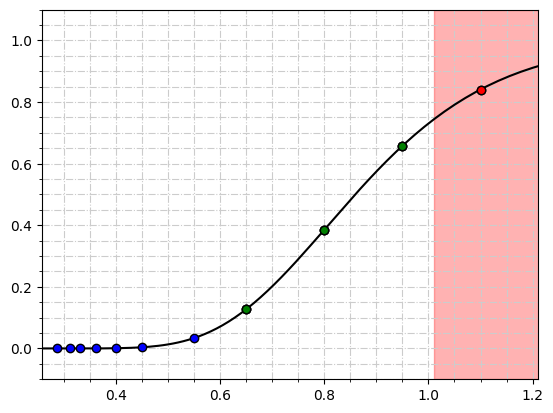

In [18]:
site = 48

fig, ax = plt.subplots()
ax.plot(IML_GRID, site_specific_fcs[site], color="k")
ax.plot(imls, site_specific_pcs[site], ls="", marker="o", mfc="b", mec="k")
ax.plot(site_specific_ideal_imls[site], site_specific_ideal_pcs[site], ls="", marker="o", mfc="r", mec="k")
ax.plot(site_specific_sel_imls[site], site_specific_sel_pcs[site], ls="", marker="o", mfc="g", mec="k")
ax.fill_betweenx([-0.1, 1.1], site_specific_max_iml[site], 2, color="r", alpha=0.3)
ax.set_xlim(imls[0]*0.9, imls[-1]*1.1)
ax.set_ylim(-0.1, 1.1)
ax.grid(which="both", ls="-.", color="0.8")
ax.minorticks_on()

## 6. Summary


### Sanity Check

I have performed a sanity check on the AvgSA values to try and find out if there is an error - or the buildings as designed just have a large capacity relative to the seismic hazard level of the sites that they are designed for.

1. I have checked the approximate AvgSA[0,3] calculated from the downloaded ESHM20 2475yr RTP hazard maps against the 2475 yr AvgSA values obtained directly from the reduced hazard model that I have run myself in OpenQuake. A visual comparison seems to indicate that the values of AvgSA from both sources are in the ballpark of each other. There doesn't seem to to be any error larger enough to acount for the 100-500% factor needed to cause a sufficient number of collapses. Based on this I think I can rule out an underestimation of the hazard. Maybe I should do a hazard run for a site at 2475yr for a couple of sites at a few SA(T1) periods to see how much the results differ from my model compared to the original ESHM20 model. --> I haven't done this yet and it would be a good safety check.

2. The second check on AvgSA[0,3] is making sure that the capacity side is correctly represented. The fragility curves of the reference structures were determined from IDA on SA(T1) and then converted to AvgSA[0,3] based on the record scaling factors that cause collapse. A separate notebook (C:\Users\clemettn\Documents\phd\notebooks\03_WP1_ground_motion_set\checks_and_tests\avgSA_conversion.ipynb) has been created to manually check the AvgSA[0,3] conversion. Comparing these values with the values from the fragilty curve conversions (014-sdof_validation_and_fragilities.ipynb, §2.7.1), the values are identical and it appears that the IM conversion of the fragility curves is valid. To double check we can rerun some of the IDAs but this time using the AvgSA[0,3] as the IM. The results below show only a very small difference (<2%) in the median collapse intensity. This I think can be attributed to the scaling and conversion process - the effects of which can be gleaned by looking at the emipirical cdf points. The pattern is very similar, however there are differences. The AvgSA IDA has vertical lines of points where failure occurs at the sam iml for several records. In the case of the converted SA results we don't see this in the same way because two records that cause collapse at the same SA IML will likely have different AvgSA values due to the different spectral shapes. From these results I have to conclude that the conversion / choice of IML is not the cause for the very high capacity

3. The third check that we can do is also on the capacity side. Currently a valid failure is recorded when the structure exceeds 20% interstorey drift. This is very large and to be honest 10% drift could also be considered a collapse. However, we can check how sensitive the results are to this assumption by running a couple of AvgSA-based IDAs on the MDOF systems with 10% and 20% drift limits to see how different the fragility curves are. 

#### Comparison of AvgSA IDA vs. Converted SA IDA

In [20]:
# compare the fragiltiy curves from teh AvgSA_03 IDA and the SA(T1) IDA for
# the 3s_cbf_dc2_10 SDOF structure
 
# Import the AvgSA_03 fragility curve directly from avgsa_03 ida
with open(ANALYSIS_ROOT / "3s_cbf_dc2_10_sdof/ida_femap695_avgsa03/collapse_fragility.json", "r") as file:
    avgsa_03_fc = json.load(file)

# Import the AvgSA_03 fragility curve directly from avgsa_03 ida v2 (different hunt parameters)
with open(ANALYSIS_ROOT / "3s_cbf_dc2_10_sdof/ida_femap695_avgsa03_v2/collapse_fragility.json", "r") as file:
    avgsa_03_2_fc = json.load(file)

# Import the AvgSA_03 fragility curve converted from the SA(T1) ida
with open(cfg["proc_data"]["sdof_fragility_curves"] / "sdof_fragility_curves.pickle", "rb") as file:
    avgsa_03_fcs_converted = pickle.load(file)
avgsa_03_fc_conv = avgsa_03_fcs_converted["3s_cbf_dc2_10"].asdict()


In [21]:
print(f"AvgSA IDA: Median = {avgsa_03_fc["median"]:.3f}   Dispersion = {avgsa_03_fc["dispersion"]:.3f}")
print(f"AvgSA IDA: Median = {avgsa_03_2_fc["median"]:.3f}   Dispersion = {avgsa_03_2_fc["dispersion"]:.3f}")
print(f"SA IDA:    Median = {avgsa_03_fc_conv["median"]:.3f}   Dispersion = {avgsa_03_fc_conv["dispersion"]:.3f}")

diff_pc = (avgsa_03_fc["median"] - avgsa_03_fc_conv["median"]) / avgsa_03_fc["median"] * 100
print(f"Diff in the median = {diff_pc:.3f}%")

imls = np.linspace(0.01, 0.5*9810)

avgsa_03_fit = lognorm.cdf(imls, s=avgsa_03_fc["dispersion"], scale=avgsa_03_fc["median"])
avgsa_03_conv_fit = lognorm.cdf(imls, s=avgsa_03_fc_conv["dispersion"], scale=avgsa_03_fc_conv["median"])

AvgSA IDA: Median = 2736.005   Dispersion = 0.180
AvgSA IDA: Median = 2738.176   Dispersion = 0.181
SA IDA:    Median = 2688.631   Dispersion = 0.180
Diff in the median = 1.731%


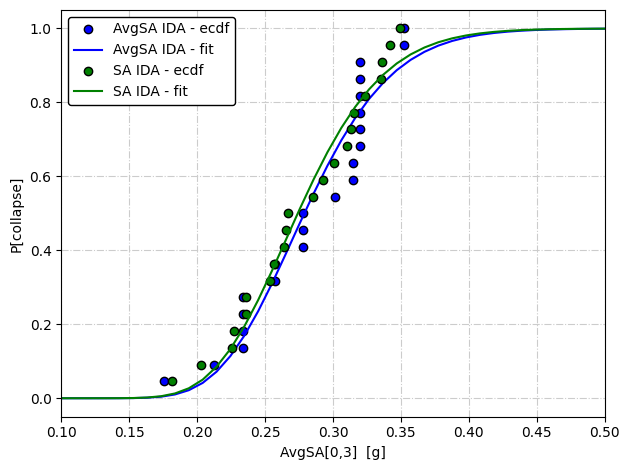

In [22]:
g = 9810   # m/s

fig, ax = plt.subplots()
ax.plot(np.array(avgsa_03_fc["efc"][0]) / 9810, avgsa_03_fc["efc"][1], ls="", marker="o", mfc="b", mec="k", label="AvgSA IDA - ecdf")
ax.plot(imls / 9810, avgsa_03_fit, color="b", label="AvgSA IDA - fit")
ax.plot(np.array(avgsa_03_fc_conv["efc"][0]) / 9810, avgsa_03_fc_conv["efc"][1], ls="", marker="o", mfc="g", mec="k", label="SA IDA - ecdf")
ax.plot(imls / 9810, avgsa_03_conv_fit, color="g", label="SA IDA - fit")

ax.grid(ls="-.",color="0.8")
ax.set_xlim(0.1, 0.5)
ax.set_xlabel("AvgSA[0,3]  [g]")
ax.set_ylabel("P[collapse]")

leg = ax.legend()
frame = leg.get_frame()
frame.set_edgecolor("k")
frame.set_facecolor("white")
frame.set_alpha(1.0)
plt.tight_layout()

## 8. Site Specific Mean Annual Frequency of Collapse (appx.)

In [23]:
from hazrisk.risk import numerical_mafe
# get the fragility curves for each site specific structure.
# Interpolated based on the vb_coeff of the site-specific design and the 
# vb_coeff of the site-independent reference designs

site_fc_curves = {}
for site_range, _ in GROUPS:
    for site_id in site_range:
        colour = CMAP(NORM(site_vb[site_id]))
        site_fc_curves[site_id] = np.column_stack([IML_GRID, site_pc_curve(site_vb[site_id])])

# integrate the fragility with respect to hazard to get the MAFC
mafc = {}
for site, hc in hcs_03_mean.items():
    idx_max = np.where(hc[:, 1] <= 0.0)[0][0]
    imls = np.logspace(min(np.log10(hc[:idx_max, 0])), max(np.log10(hc[:idx_max, 0])), 100)

    # interpolate the fragility and hazard are defined at the same IMLs
    H = np.exp(np.interp(np.log(imls), np.log(hc[:idx_max, 0]), np.log(hc[:idx_max, 1])))
    Pc = (np.interp(imls, site_fc_curves[site][:, 0], site_fc_curves[site][:, 1]))
    
    # calculate the MAFC
    mafc[site] = numerical_mafe(H, Pc)

mafcs = list(mafc.values())

Text(0.5, 0.00021, 'EC8:Annex F limit')

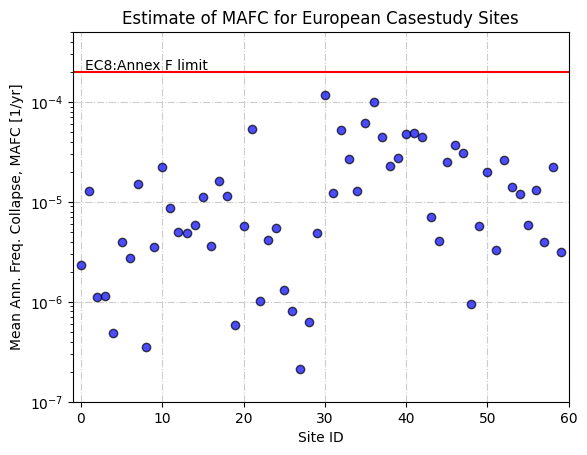

In [24]:
fig, ax = plt.subplots()
ax.semilogy(mafcs, ls="", marker="o", mfc="b", mec="k", alpha=0.7)
ax.hlines(2e-4, -1, 60, color="r")
ax.grid(ls="-.", color="0.8")
ax.set_ylabel("Mean Ann. Freq. Collapse, MAFC [1/yr]")
ax.set_xlabel("Site ID")
ax.set_ylim(1e-7, 5e-4)
ax.set_xlim(-1, 60)
ax.set_title("Estimate of MAFC for European Casestudy Sites")
ax.annotate("EC8:Annex F limit", (0.5, 2.1e-4))